In [1]:
print('c')

c


In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from torch.utils.data import Subset
# Включаем cuDNN автотюнинг для ускорения сверточных сетей на GPU
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()

# Проверяем доступность GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")
if torch.cuda.is_available():
    print(f"Имя видеокарты: {torch.cuda.get_device_name(0)}")

Используемое устройство: cuda:0
Имя видеокарты: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [ ]:
DATA_DIR = '../data' 


data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


train_dataset_full = datasets.ImageFolder(DATA_DIR, transform=data_transforms['train'])
val_dataset_full = datasets.ImageFolder(DATA_DIR, transform=data_transforms['val'])

class_names = train_dataset_full.classes
print(f"Обнаружено классов: {len(class_names)}")
print(f"Список классов: {class_names}")

# случайные индексы для сплита (80% / 20%)
num_objects = len(train_dataset_full)
train_size = int(0.8 * num_objects)
val_size = num_objects - train_size

# Фиксируем генератор для воспроизводимости разделения индексов
indices = torch.randperm(num_objects).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# 4. Создаем подвыборки (Subset), где у каждой свои чистые трансформации
train_data = Subset(train_dataset_full, train_indices)
val_data = Subset(val_dataset_full, val_indices)

# 5. производительные DataLoaders
image_datasets = {'train': train_data, 'val': val_data}
dataloaders = {
    'train': DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True),
    'val': DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
print(f"Размер обучающей выборки: {dataset_sizes['train']}")
print(f"Размер валидационной выборки: {dataset_sizes['val']}")

Обнаружено классов: 11
Список классов: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']
Размер обучающей выборки: 5489
Размер валидационной выборки: 1373


In [52]:
model_name = "resnet18" 

if model_name == "resnet18":
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
elif model_name == "resnet50":
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Разрешаем всем параметрам обучаться (разморозка для полноценного Fine-tuning)
for param in model.parameters():
    param.requires_grad = True

# Динамически берем количество входных признаков (у ResNet18 это 512, у ResNet50 это 2048)
num_ftrs = model.fc.in_features

# Классификационный блок с Dropout
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),  # Защита от переобучения
    nn.Linear(num_ftrs, len(class_names))
)

# Переносим модель на целевое устройство (GPU / CPU)
model = model.to(device)

# Функция потерь
criterion = nn.CrossEntropyLoss()

# Оптимизатор Adam с регуляризацией весов L2 (weight_decay)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Заменяем жесткий StepLR на плавный косинусный планировщик. 
# T_max равен общему числу эпох обучения (например, 5)
NUM_EPOCHS = 5
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=5):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    # истории метрик
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Эпоха {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Включаем режим обучения (работает Dropout)
            else:
                model.eval()   # Включаем режим валидации (Dropout выключен)

            running_loss = 0.0
            running_corrects = 0

            # Итерируемся по батчам данных
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Считаем градиенты только во время фазы Train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Шаг планировщика вызываем строго после завершения фазы обучения
            if phase == 'train' and 'scheduler' in globals():
                scheduler.step()

            # Считаем средние метрики за эпоху
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Запись истории
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            # Фиксация наилучших весов
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Обучение завершено за {time_elapsed // 60:.0f}м {time_elapsed % 60:.0f}с')
    print(f'Лучшая валидационная точность (Accuracy): {best_acc:.4f}')

    # Загружаем лучшие веса обратно в модель
    model.load_state_dict(best_model_wts)
    return model, history, time_elapsed

# Запуск 
model, history, training_time = train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS)

Эпоха 1/5
----------
Train Loss: 0.7243 Acc: 0.7628
Val Loss: 0.3408 Acc: 0.8871

Эпоха 2/5
----------
Train Loss: 0.3479 Acc: 0.8867
Val Loss: 0.2889 Acc: 0.9024

Эпоха 3/5
----------
Train Loss: 0.2411 Acc: 0.9191
Val Loss: 0.2953 Acc: 0.9039

Эпоха 4/5
----------
Train Loss: 0.1844 Acc: 0.9452
Val Loss: 0.2666 Acc: 0.9155

Эпоха 5/5
----------
Train Loss: 0.1450 Acc: 0.9557
Val Loss: 0.2523 Acc: 0.9162

Обучение завершено за 4м 23с
Лучшая валидационная точность (Accuracy): 0.9162


In [62]:
# режим оценки
model.eval()
all_preds = []
all_labels = []

# предсказания по валидационной выборке
with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# расчет и вывод метрик 
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
print(f"Итоговый Weighted F1-Score: {f1_weighted:.4f}")

print("\nПодробный отчет о классификации по классам погоды:")
print(classification_report(all_labels, all_preds, target_names=class_names))


os.makedirs('weights', exist_ok=True)


torch.save(model.state_dict(), 'weights/resnet18.pth')
print("\nСвежие веса (91.62%) успешно записаны в: weights/resnet18.pth")

Итоговый Weighted F1-Score: 0.9167

Подробный отчет о классификации по классам погоды:
              precision    recall  f1-score   support

         dew       0.96      0.97      0.97       159
     fogsmog       0.92      0.94      0.93       170
       frost       0.83      0.86      0.84        84
       glaze       0.84      0.86      0.85       125
        hail       0.98      0.96      0.97       112
   lightning       1.00      0.99      0.99        77
        rain       0.95      0.94      0.95       101
     rainbow       0.98      1.00      0.99        49
        rime       0.93      0.87      0.90       252
   sandstorm       0.93      0.93      0.93       129
        snow       0.78      0.85      0.81       115

    accuracy                           0.92      1373
   macro avg       0.92      0.92      0.92      1373
weighted avg       0.92      0.92      0.92      1373


Свежие веса (91.62%) успешно записаны в: weights/resnet18.pth


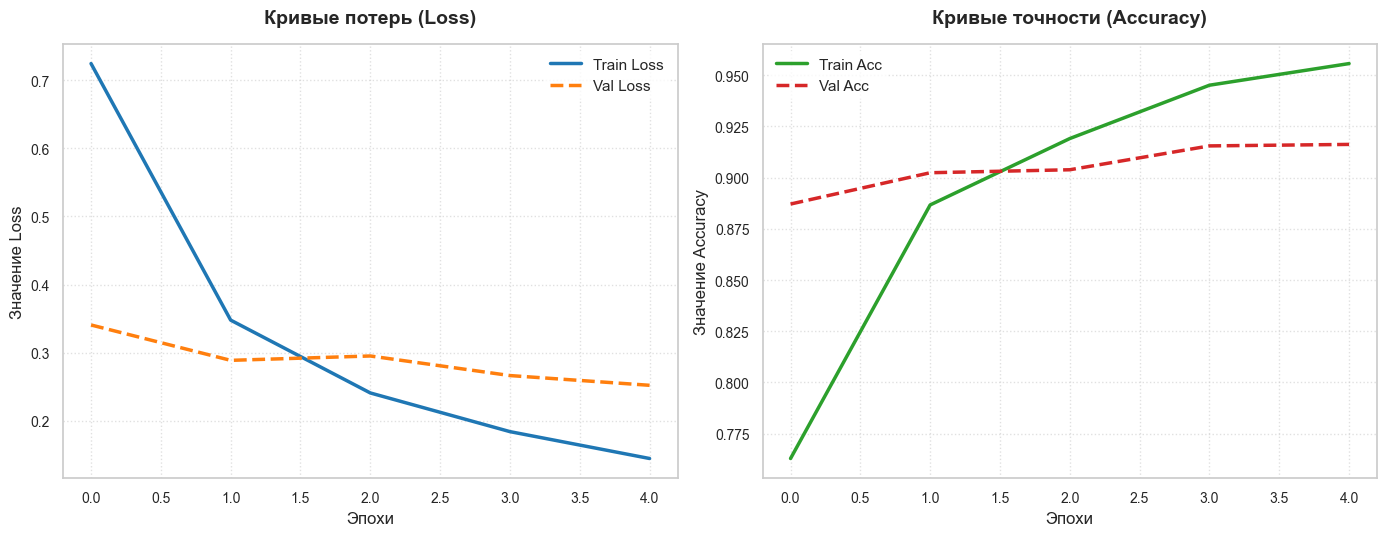

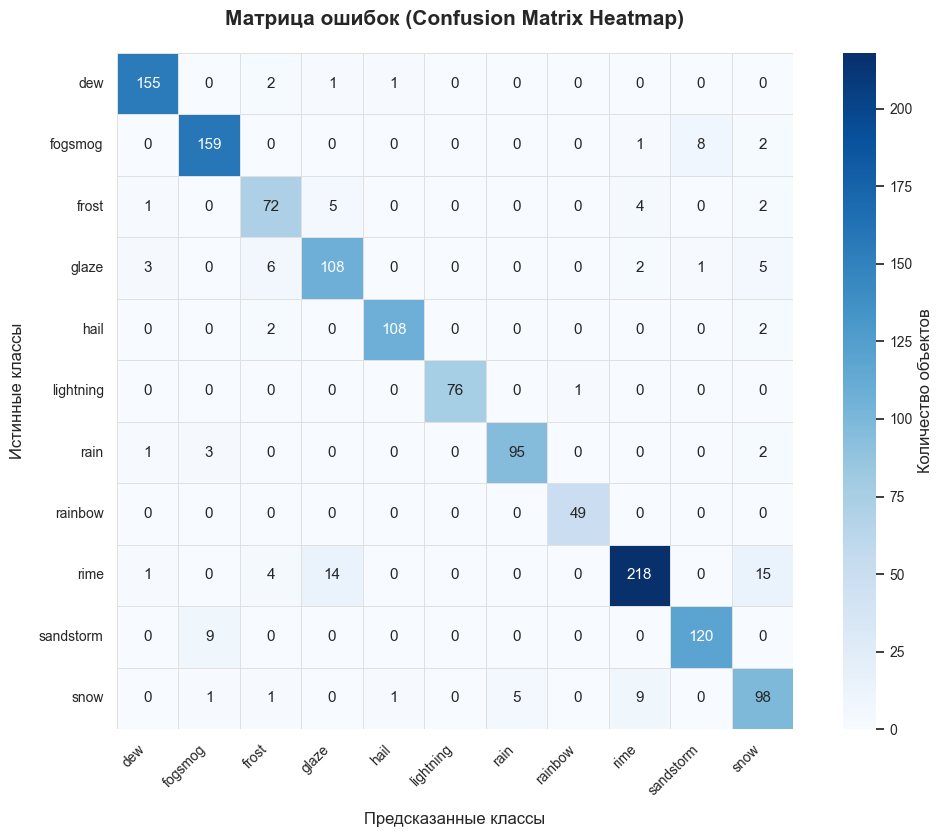

In [63]:
# Устанавливаем чистый современный стиль графиков
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# --- 1. КРИВЫЕ ОБУЧЕНИЯ (Loss и Accuracy) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# График потерь (Loss)
axes[0].plot(history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2.5, linestyle='-')
axes[0].plot(history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2.5, linestyle='--')
axes[0].set_title('Кривые потерь (Loss)', pad=15, fontweight='bold')
axes[0].set_xlabel('Эпохи')
axes[0].set_ylabel('Значение Loss')
axes[0].legend(frameon=True, facecolor='white', edgecolor='none')
axes[0].grid(True, linestyle=':', alpha=0.6)

# График точности (Accuracy)
axes[1].plot(history['train_acc'], label='Train Acc', color='#2ca02c', linewidth=2.5, linestyle='-')
axes[1].plot(history['val_acc'], label='Val Acc', color='#d62728', linewidth=2.5, linestyle='--')
axes[1].set_title('Кривые точности (Accuracy)', pad=15, fontweight='bold')
axes[1].set_xlabel('Эпохи')
axes[1].set_ylabel('Значение Accuracy')
axes[1].legend(frameon=True, facecolor='white', edgecolor='none')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()


# --- 2. МАТРИЦА ОШИБОК (Confusion Matrix) ---
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(11, 8.5))
# Использование палитры 'Blues' обеспечивает строгий академический вид
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names,
    square=True,
    cbar_kws={'label': 'Количество объектов'},
    linewidths=0.5,
    linecolor='#e0e0e0',
    annot_kws={"size": 11, "weight": "medium"}
)

plt.title('Матрица ошибок (Confusion Matrix Heatmap)', pad=20, fontsize=15, fontweight='bold')
plt.ylabel('Истинные классы', labelpad=10)
plt.xlabel('Предсказанные классы', labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [58]:
checkpoint = torch.load('weights/resnet18.pth', map_location='cpu')

# Смотрим на размер выходного слоя, чтобы убедиться, что это новая модель
print("Размер выходного слоя:", checkpoint['fc.1.bias'].shape[0]) 

# Проверьте, какой список классов выдавала ячейка №2:
print( class_names)

Размер выходного слоя: 11
['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [59]:
print(full_dataset.classes)

['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']
